In [3]:
%load_ext autoreload
%autoreload 2

In [62]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.tri as tri
#import xarray
import pandas as pd
import os
import sys
import glob
import h5py as h5
import math

In [45]:
import rex

In [46]:
pathwestcoast = '/datasets/US_wave/v1.0.0/West_Coast/West_Coast_wave_2010.h5'
a = h5.File(pathwestcoast,'r')

In [47]:
# list variables
a.keys()

<KeysViewHDF5 ['coordinates', 'directionality_coefficient', 'energy_period', 'maximum_energy_direction', 'mean_absolute_period', 'mean_wave_direction', 'mean_zero-crossing_period', 'meta', 'omni-directional_wave_power', 'peak_period', 'significant_wave_height', 'spectral_width', 'time_index', 'water_depth']>

In [48]:
# pull attributes of parameters listed above
a['significant_wave_height']

<HDF5 dataset "significant_wave_height": shape (2920, 699904), type "<f4">

In [49]:
# Plot mean wave direction

#meta = pd.DataFrame(a['meta'][...])
mwd = a['mean_wave_direction'][:]
print(mwd)

coord = a['coordinates'][:]
print(coord)
print(coord.shape)
print(mwd.shape)

MemoryError: Unable to allocate 7.61 GiB for an array with shape (2920, 699904) and data type float32

In [50]:
lats = coord[:,0]
print(lats)
lons = coord[:,1]
print(lons)

[48.8641 48.8418 48.8193 ... 37.4631 37.4615 37.4614]
[-125.386 -125.446 -125.504 ... -122.026 -122.026 -122.025]


In [ ]:
# mean wave direction from only one time
mwd_0 = mwd[0,:]

# check dim sizes
print(a['coordinates'])
print(a['mean_wave_direction'])

print(lats.shape)
print(lats)

print(lons.shape)
print(lons)

print(mwd_0.shape)
print(mwd_0)

mwd_0[mwd_0 == -999] = math.nan
print(mwd_0)

# create evenly spaced xi,yi over lon/lat ranges

xi = np.linspace(np.min(lons), np.max(lons), 500)
yi = np.linspace(np.min(lats), np.max(lats), 500)

# Linearly interpolate the data (lons, lats) on a grid defined by (xi, yi).
triang = tri.Triangulation(lons, lats)
interpolator = tri.LinearTriInterpolator(triang, mwd_0)
Xi, Yi = np.meshgrid(xi, yi)
zi = interpolator(Xi, Yi)

fig1,ax1 = plt.subplots(1,1)
ax1.contour(xi, yi, zi, levels=14, linewidths=0.5, colors='k')
cntr1 = ax1.contourf(xi, yi, zi, levels=14, cmap="RdBu_r")

fig.colorbar(cntr1, ax=ax1)
ax1.plot(x, y, 'ko', ms=3)
ax1.set(xlim=(-2, 2), ylim=(-2, 2))
ax1.set_title('grid and contour (%d points, %d grid points)' %
              (npts, ngridx * ngridy))

plt.show()

In [60]:
# now plot a contour plot
X, Y = np.meshgrid(lons, lats, sparse=True)

In [40]:
Z = pd.DataFrame(mwd_0).round()
print(Z)

            0
0        56.0
1        50.0
2        54.0
3        57.0
4        62.0
...       ...
699899 -999.0
699900 -999.0
699901 -999.0
699902 -999.0
699903 -999.0

[699904 rows x 1 columns]


TypeError: Input z must be at least a (2, 2) shaped array, but has shape (699904, 1)

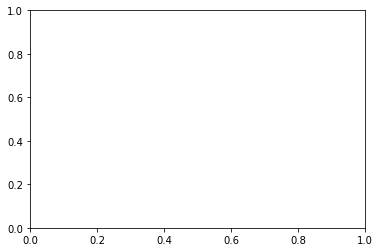

In [41]:
fig,ax = plt.subplots(1,1)
cp = ax.contourf(X,Y,Z)

fig.colorbar(cp) # Add a colorbar to a plot
ax.set_title('Filled Contours Plot')
#ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
plt.show()

In [12]:
time = a['time_index']
print(time)

<HDF5 dataset "time_index": shape (2920,), type "|S25">


# test from examples:

In [13]:
# Extract the average wave height
# Open .h5 file
with h5.File('/datasets/US_wave/v1.0.0/West_Coast/West_Coast_wave_2010.h5', mode='r') as f:
    # Extract meta data and convert from records array to DataFrame
    meta = pd.DataFrame(f['meta'][...])
    # Significant Wave Height
    swh = f['significant_wave_height']
    # Extract scale factor
   # scale_factor = swh.attrs['scale_factor']
    # Extract, average, and unscale wave height
    mean_swh = swh[...].mean(axis=0) 

# Add mean wave height to meta data
meta['Average Wave Height'] = mean_swh

print(mean_swh)


[ 1.4397438e+00  2.2681565e+00  2.3494923e+00 ...  2.1442116e-04
 -9.0000000e+00  8.0886901e-05]


In [14]:
# Extract time-series data for a single site
# Open .h5 file
with h5.File('/datasets/US_wave/v1.0.0/West_Coast/West_Coast_wave_2010.h5', mode='r') as f:
    # Extract time_index and convert to datetime
    # NOTE: time_index is saved as byte-strings and must be decoded
    time_index = pd.to_datetime(f['time_index'][...].astype(str))
    # Initialize DataFrame to store time-series data
    time_series = pd.DataFrame(index=time_index)
    # Extract wave height, direction, and period
    for var in ['significant_wave_height', 'mean_wave_direction',
                'mean_absolute_period']:
        # Get dataset
        ds = f[var]
        # Extract scale factor
    #   scale_factor = ds.attrs['scale_factor']
        # Extract site 100 and add to DataFrame
        time_series[var] = ds[:, 100] 
        print(time_series['significant_wave_height'])


2010-01-01 00:00:00+00:00    3.96809
2010-01-01 03:00:00+00:00    4.14000
2010-01-01 06:00:00+00:00    5.17250
2010-01-01 09:00:00+00:00    6.73865
2010-01-01 12:00:00+00:00    8.21086
                              ...   
2010-12-31 09:00:00+00:00    3.01169
2010-12-31 12:00:00+00:00    2.93514
2010-12-31 15:00:00+00:00    2.95853
2010-12-31 18:00:00+00:00    3.12255
2010-12-31 21:00:00+00:00    3.48675
Name: significant_wave_height, Length: 2920, dtype: float32
2010-01-01 00:00:00+00:00    3.96809
2010-01-01 03:00:00+00:00    4.14000
2010-01-01 06:00:00+00:00    5.17250
2010-01-01 09:00:00+00:00    6.73865
2010-01-01 12:00:00+00:00    8.21086
                              ...   
2010-12-31 09:00:00+00:00    3.01169
2010-12-31 12:00:00+00:00    2.93514
2010-12-31 15:00:00+00:00    2.95853
2010-12-31 18:00:00+00:00    3.12255
2010-12-31 21:00:00+00:00    3.48675
Name: significant_wave_height, Length: 2920, dtype: float32
2010-01-01 00:00:00+00:00    3.96809
2010-01-01 03:00:00+00:00    

# Read observations

In [43]:
import netCDF4 as nc

fn = '/projects/hindcastra/Cook_Inlet/46076.nc'
ds = nc.Dataset(fn)

# Variables in File
print(ds)

for var in ds.variables.values():
    print(var)
    
# print wind speed    
print(ds['WSPD'])

# access data values
windspeed = ds['WSPD'][:]

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Description: 46076 NDBC Bulk Parameter Data
    rawdata: National Data Buoy Center 
www.ndbc.noaa.gov
    Author: ggarcia@coas.oregonstate.edu 
Nearshore Modeling Group
    Created: Mon Dec  5 11:15:57 2022
    Software: Created with Python 2.7.15 |Anaconda, Inc.| (default, May  1 2018, 23:32:55) 
[GCC 7.2.0]
    NetCDF_Lib: 4.6.1 of May 13 2018 11:35:39 $
    Script: /qfs/people/garc525/opt/python/pynmd/data/ndbc.pyc
    dimensions(sizes): wave_time(117931)
    variables(dimensions): float64 wave_time(wave_time), float64 WDIR(wave_time), float64 WSPD(wave_time), float64 GST(wave_time), float64 WVHT(wave_time), float64 DPD(wave_time), float64 APD(wave_time), float64 MWD(wave_time), float64 PRES(wave_time), float64 ATMP(wave_time), float64 WTMP(wave_time)
    groups: 
<class 'netCDF4._netCDF4.Variable'>
float64 wave_time(wave_time)
    units: seconds since 1900-01-01 00:00:00
    long_name: measure

# Plot the obs (time series)